# AI Resume / Candidate Screening System
### Machine Learning Task 3 – Future Interns

Developed an intelligent NLP-based resume screening system
that automatically analyzes resumes, extracts skills,
matches candidates with job descriptions,
ranks applicants based on relevance,
and identifies missing skills.

# 1. Problem Statement

Hiring teams receive hundreds of resumes for a single job role.
Manual screening is time-consuming, inconsistent,
and difficult to scale.
source

Raw resume text often contains:
- punctuation
- stopwords
- special characters
- inconsistent formatting

To improve text quality,
the following preprocessing steps are applied:
- lowercase conversion
- punctuation removal
- stopword removal
- tokenization
- lemmatization

## 5.1 Convert Text to Lowercase
## 5.2 Remove Punctuation and Special Characters
## 5.3 Remove Stopwords
## 5.4 Apply Lemmatization

In [248]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_resume(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', ' ', text)

    # remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenization
    words = text.split()

    # remove stopwords + lemmatization
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(cleaned_words)

In [249]:
df['Cleaned_Resume'] = df['Resume_str'].apply(clean_resume)

# 6. Resume Text Visualization

WordCloud-style exploration helps identify
commonly occurring words and skills
in different resumes.

This provides better understanding
of important keywords present in the dataset.

In [250]:
print("ORIGINAL RESUME:\n")
print(df['Resume_str'][0])

print("\n" + "="*80 + "\n")

print("CLEANED RESUME:\n")
print(df['Cleaned_Resume'][0])

ORIGINAL RESUME:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory c

In [251]:
def extract_text_from_pdf(pdf_path):

    text = ""

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()

            if page_text:
                text += page_text + " "

    return text

# 7. Skill Extraction using NLP

Skill extraction is one of the most important
parts of the resume screening process.

The system identifies technical and professional skills
from:
- resumes
- job descriptions

using predefined skill dictionaries and NLP matching techniques.

## 7.1 Create Skill Database

In [252]:
skills_db = [
    'python',
    'java',
    'c++',
    'sql',
    'mysql',
    'mongodb',
    'excel',
    'power bi',
    'tableau',
    'machine learning',
    'deep learning',
    'data science',
    'nlp',
    'tensorflow',
    'keras',
    'pytorch',
    'scikit learn',
    'statistics',
    'data analysis',
    'html',
    'css',
    'javascript',
    'react',
    'nodejs',
    'aws',
    'docker',
    'kubernetes',
    'git',
    'communication',
    'leadership',
    'project management'
]

## 7.2 Extract Skills from Resumes

In [253]:
def extract_skills(text):

    text = text.lower()

    extracted_skills = set()

    for skill in skills_db:
        if skill in text:
            extracted_skills.add(skill)

    return list(extracted_skills)

In [254]:
df['Extracted_Skills'] = df['Cleaned_Resume'].apply(extract_skills)

In [255]:
print("CATEGORY:\n")
print(df['Category'][0])

print("\n" + "="*80 + "\n")

print("EXTRACTED SKILLS:\n")
print(df['Extracted_Skills'][0])

CATEGORY:

HR


EXTRACTED SKILLS:

['leadership', 'data analysis']


In [256]:
df['Skill_Count'] = df['Extracted_Skills'].apply(len)

print(df[['Category', 'Skill_Count']].head())

  Category  Skill_Count
0       HR            2
1       HR            3
2       HR            3
3       HR            2
4       HR            4


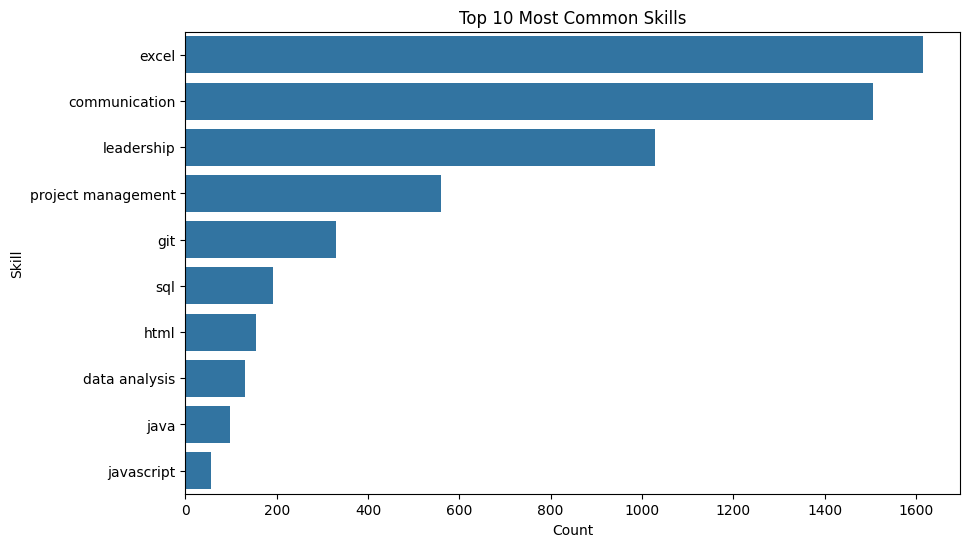

In [257]:
from collections import Counter

all_skills = []

for skill_list in df['Extracted_Skills']:
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counts.most_common(10),
    columns=['Skill', 'Count']
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Count',
    y='Skill',
    data=top_skills
)

plt.title("Top 10 Most Common Skills")

plt.show()

# 9. Job Description Processing

This section prepares the job description input
used for candidate matching and ranking.

The job description is later compared against resumes
for skill alignment and semantic similarity scoring.

In [258]:
job_description = input("Paste the Job Description here:\n")

Paste the Job Description here:
We are hiring a Machine Learning Engineer.  Required Skills: Python, Machine Learning, SQL, TensorFlow, NLP, Data Analysis, Deep Learning, Git, AWS  Experience in AI project development is preferred.


In [259]:
print(job_description)

We are hiring a Machine Learning Engineer.  Required Skills: Python, Machine Learning, SQL, TensorFlow, NLP, Data Analysis, Deep Learning, Git, AWS  Experience in AI project development is preferred.


In [260]:
model = SentenceTransformer('all-MiniLM-L6-v2')

resume_texts = df['Cleaned_Resume'].tolist()

resume_embeddings = model.encode(resume_texts)

jd_embedding = model.encode([job_description])

similarity_scores = cosine_similarity(
    jd_embedding,
    resume_embeddings
)

df['Similarity_Score'] = similarity_scores[0] * 100

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 10. TF-IDF Feature Engineering

Machine Learning algorithms cannot directly process text data.

TF-IDF Vectorization converts textual information
into numerical feature vectors
by measuring the importance of words
within resumes and job descriptions.

# 11. Resume-to-Job Similarity Calculation

Cosine Similarity is used to measure
how closely a resume matches
a given job description.

Higher similarity scores indicate
better alignment between candidate skills
and job requirements.

In [261]:
df[['Category', 'Similarity_Score']].head()

,Category,Similarity_Score
0,HR,10.795598
1,HR,15.908633
2,HR,17.267872
3,HR,15.207871
4,HR,18.646402


In [262]:
ranked_df = df.sort_values(
    by='Similarity_Score',
    ascending=False
)

In [263]:
ranked_df[
    ['Category', 'Similarity_Score', 'Extracted_Skills']
].head(10)

,Category,Similarity_Score,Extracted_Skills
1710,ENGINEERING,40.891922,"[communication, leadership, git, project manag..."
1762,ENGINEERING,39.228977,"[python, data analysis, html, machine learning..."
987,BPO,38.974876,"[communication, java, html, git, javascript, p..."
297,INFORMATION-TECHNOLOGY,38.730476,"[communication, java, mysql, html, git, javasc..."
124,DESIGNER,38.309982,"[java, mysql, git, project management, sql]"
1727,ENGINEERING,38.204533,"[leadership, excel]"
1932,CONSTRUCTION,37.479748,"[java, mysql, html, javascript, project manage..."
926,AGRICULTURE,37.014503,"[communication, python, java, html, leadership..."
1348,AUTOMOBILE,34.506962,"[python, java, data analysis, machine learning..."
2457,AVIATION,34.423164,"[java, html, data analysis, git, aws, sql]"


## 7.3 Extract Skills from Job Description

The same skill dictionary is applied to the job description
so the system can compare required skills
against candidate resumes.

In [264]:
jd_skills = extract_skills(job_description)

print("JOB DESCRIPTION SKILLS:\n")
print(jd_skills)

JOB DESCRIPTION SKILLS:

['deep learning', 'python', 'nlp', 'data analysis', 'git', 'machine learning', 'tensorflow', 'aws', 'sql']


In [265]:
def find_missing_skills(candidate_skills, jd_skills):

    missing = []

    for skill in jd_skills:
        if skill not in candidate_skills:
            missing.append(skill)

    return missing

# 14. Skill Gap Analysis

Skill Gap Analysis identifies
important skills required for the job
that are missing in candidate resumes.

This helps recruiters:
- evaluate candidate readiness
- identify training needs
- make better hiring decisions

In [266]:
df['Missing_Skills'] = df['Extracted_Skills'].apply(
    lambda x: find_missing_skills(x, jd_skills)
)

In [267]:
df['Matched_Skills_Count'] = df['Extracted_Skills'].apply(
    lambda x: len(set(x).intersection(set(jd_skills)))
)

In [268]:
ranked_df = df.sort_values(
    by='Similarity_Score',
    ascending=False
)

ranked_df[
    [
        'Category',
        'Similarity_Score',
        'Extracted_Skills',
        'Missing_Skills',
        'Matched_Skills_Count'
    ]
].head(10)

,Category,Similarity_Score,Extracted_Skills,Missing_Skills,Matched_Skills_Count
1710,ENGINEERING,40.891922,"[communication, leadership, git, project manag...","[deep learning, python, nlp, data analysis, ma...",1
1762,ENGINEERING,39.228977,"[python, data analysis, html, machine learning...","[deep learning, nlp, git, tensorflow, aws]",4
987,BPO,38.974876,"[communication, java, html, git, javascript, p...","[deep learning, python, nlp, data analysis, ma...",2
297,INFORMATION-TECHNOLOGY,38.730476,"[communication, java, mysql, html, git, javasc...","[deep learning, python, nlp, data analysis, ma...",3
124,DESIGNER,38.309982,"[java, mysql, git, project management, sql]","[deep learning, python, nlp, data analysis, ma...",2
1727,ENGINEERING,38.204533,"[leadership, excel]","[deep learning, python, nlp, data analysis, gi...",0
1932,CONSTRUCTION,37.479748,"[java, mysql, html, javascript, project manage...","[deep learning, python, nlp, data analysis, gi...",1
926,AGRICULTURE,37.014503,"[communication, python, java, html, leadership...","[deep learning, nlp, data analysis, git, machi...",3
1348,AUTOMOBILE,34.506962,"[python, java, data analysis, machine learning...","[deep learning, nlp, git, tensorflow, aws]",4
2457,AVIATION,34.423164,"[java, html, data analysis, git, aws, sql]","[deep learning, python, nlp, machine learning,...",4


In [269]:
top_candidate = ranked_df.iloc[0]

print("TOP CANDIDATE ANALYSIS")
print("="*60)

print(f"Category: {top_candidate['Category']}")

print(f"\nMatch Score: {top_candidate['Similarity_Score']:.2f}%")

print("\nMatched Skills:")
print(top_candidate['Extracted_Skills'])

print("\nMissing Skills:")
print(top_candidate['Missing_Skills'])

print(f"\nMatched Skills Count: {top_candidate['Matched_Skills_Count']}")

TOP CANDIDATE ANALYSIS
Category: ENGINEERING

Match Score: 40.89%

Matched Skills:
['communication', 'leadership', 'git', 'project management', 'excel']

Missing Skills:
['deep learning', 'python', 'nlp', 'data analysis', 'machine learning', 'tensorflow', 'aws', 'sql']

Matched Skills Count: 1


# 16. Final Candidate Evaluation Results

This section displays:
- candidate rankings
- match percentages
- extracted skills
- missing skills
- recommendation summaries

The output simulates a real-world
AI-based Applicant Tracking System (ATS).

In [270]:
total_required_skills = len(jd_skills)

df['Skill_Match_Percentage'] = (
    df['Matched_Skills_Count'] / total_required_skills
) * 100

# 12. Weighted Skill Matching

Not all skills have equal importance.

This system assigns higher weights
to critical skills such as:
- Python
- Machine Learning
- SQL
- NLP

Weighted scoring improves the realism
and effectiveness of candidate evaluation.

In [271]:
df[
    [
        'Category',
        'Matched_Skills_Count',
        'Skill_Match_Percentage'
    ]
].head()

,Category,Matched_Skills_Count,Skill_Match_Percentage
0,HR,1,11.111111
1,HR,1,11.111111
2,HR,0,0.000000
3,HR,0,0.000000
4,HR,1,11.111111


In [272]:
df['Final_Score'] = (
    (0.75 * df['Similarity_Score']) +
    (0.25 * df['Skill_Match_Percentage'])
)

In [273]:
final_ranked_df = df.sort_values(
    by='Final_Score',
    ascending=False
)

# 13. Candidate Ranking System

Candidates are ranked based on:
- similarity score
- weighted skill score
- overall relevance to the job role

The final ranking helps recruiters
identify the most suitable candidates quickly.

In [274]:
final_ranked_df[
    [
        'Category',
        'Similarity_Score',
        'Skill_Match_Percentage',
        'Final_Score',
        'Extracted_Skills',
        'Missing_Skills'
    ]
].head(10)

,Category,Similarity_Score,Skill_Match_Percentage,Final_Score,Extracted_Skills,Missing_Skills
1762,ENGINEERING,39.228977,44.444444,40.532845,"[python, data analysis, html, machine learning...","[deep learning, nlp, git, tensorflow, aws]"
1717,ENGINEERING,32.251694,55.555556,38.077659,"[python, leadership, git, machine learning, sc...","[deep learning, nlp, data analysis, aws]"
297,INFORMATION-TECHNOLOGY,38.730476,33.333333,37.381191,"[communication, java, mysql, html, git, javasc...","[deep learning, python, nlp, data analysis, ma..."
1348,AUTOMOBILE,34.506962,44.444444,36.991333,"[python, java, data analysis, machine learning...","[deep learning, nlp, git, tensorflow, aws]"
2457,AVIATION,34.423164,44.444444,36.928484,"[java, html, data analysis, git, aws, sql]","[deep learning, python, nlp, machine learning,..."
926,AGRICULTURE,37.014503,33.333333,36.094211,"[communication, python, java, html, leadership...","[deep learning, nlp, data analysis, git, machi..."
987,BPO,38.974876,22.222222,34.786713,"[communication, java, html, git, javascript, p...","[deep learning, python, nlp, data analysis, ma..."
124,DESIGNER,38.309982,22.222222,34.288042,"[java, mysql, git, project management, sql]","[deep learning, python, nlp, data analysis, ma..."
1750,ENGINEERING,33.992317,33.333333,33.827571,"[communication, python, leadership, git, proje...","[deep learning, nlp, data analysis, machine le..."
1710,ENGINEERING,40.891922,11.111111,33.446719,"[communication, leadership, git, project manag...","[deep learning, python, nlp, data analysis, ma..."


In [275]:
top_candidate = final_ranked_df.iloc[0]

print("FINAL TOP CANDIDATE ANALYSIS")
print("="*60)

print(f"Category: {top_candidate['Category']}")

print(f"\nSimilarity Score: {top_candidate['Similarity_Score']:.2f}%")

print(f"\nSkill Match Percentage: {top_candidate['Skill_Match_Percentage']:.2f}%")

print(f"\nFinal Hybrid Score: {top_candidate['Final_Score']:.2f}%")

print("\nExtracted Skills:")
print(top_candidate['Extracted_Skills'])

print("\nMissing Skills:")
print(top_candidate['Missing_Skills'])

print("\nRECRUITER EXPLANATION")
print("="*60)

print(
    f"This candidate ranked highest because they achieved "
    f"{top_candidate['Similarity_Score']:.2f}% semantic similarity "
    f"and matched {top_candidate['Matched_Skills_Count']} required skills."
)

FINAL TOP CANDIDATE ANALYSIS
Category: ENGINEERING

Similarity Score: 39.23%

Skill Match Percentage: 44.44%

Final Hybrid Score: 40.53%

Extracted Skills:
['python', 'data analysis', 'html', 'machine learning', 'tableau', 'excel', 'sql']

Missing Skills:
['deep learning', 'nlp', 'git', 'tensorflow', 'aws']

RECRUITER EXPLANATION
This candidate ranked highest because they achieved 39.23% semantic similarity and matched 4 required skills.


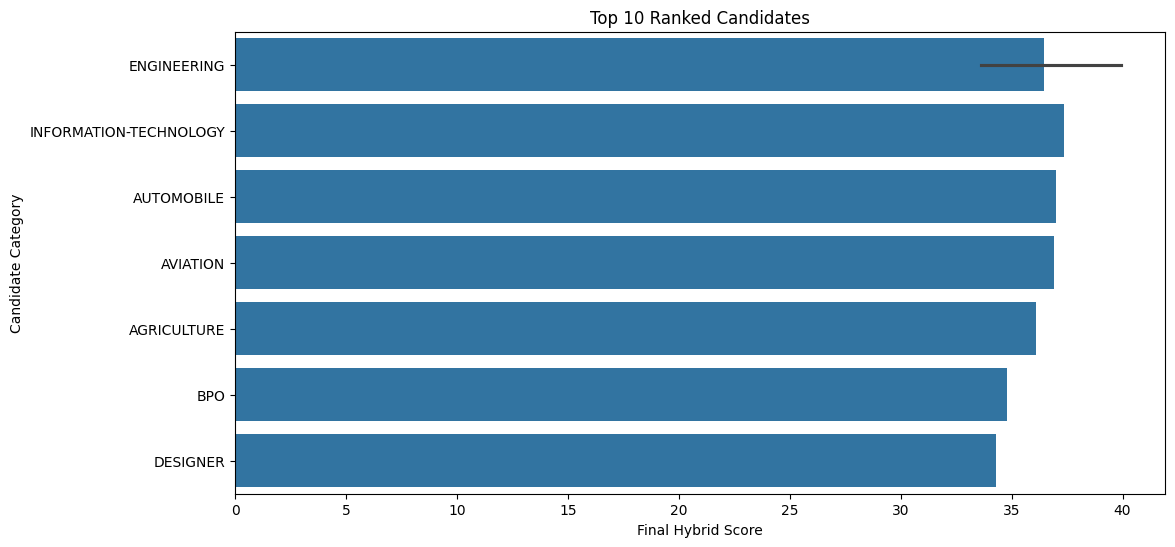

In [276]:
top_10 = final_ranked_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Final_Score',
    y='Category',
    data=top_10
)

plt.title("Top 10 Ranked Candidates")
plt.xlabel("Final Hybrid Score")
plt.ylabel("Candidate Category")

plt.show()

# 15. Data Visualization

Visualizations are used to:
- compare candidate scores
- analyze skill distributions
- understand ranking performance

These visual insights improve interpretability
for HR teams and recruiters.

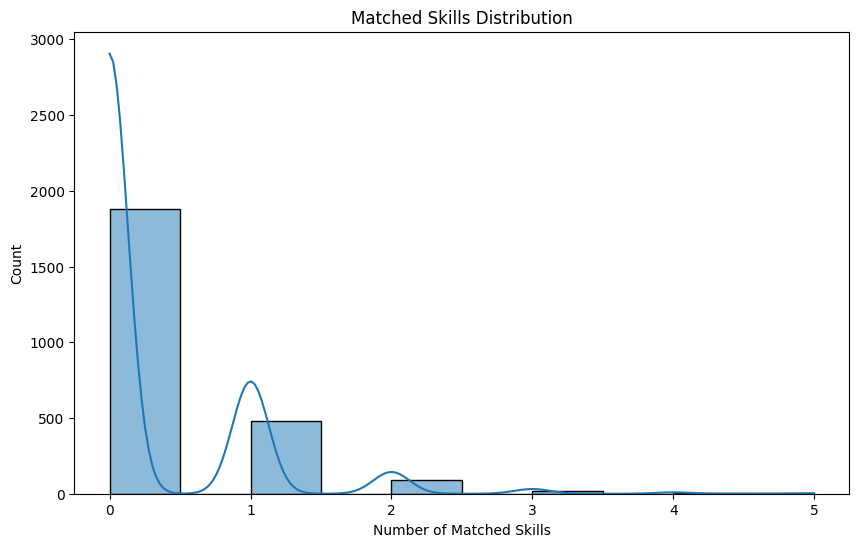

In [277]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Matched_Skills_Count'],
    bins=10,
    kde=True
)

plt.title("Matched Skills Distribution")
plt.xlabel("Number of Matched Skills")

plt.show()

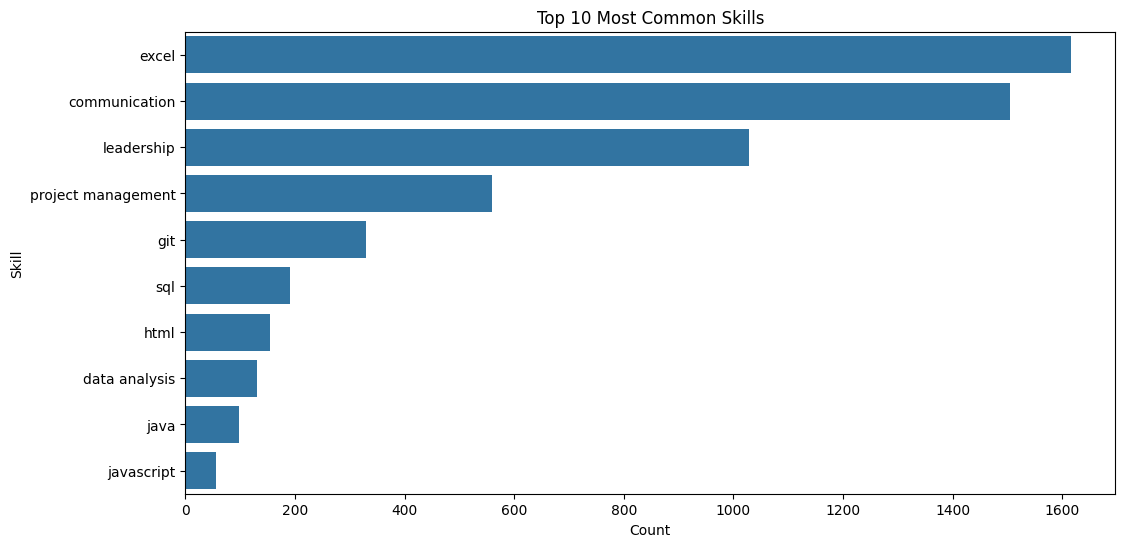

In [278]:
from collections import Counter

all_skills = []

for skill_list in df['Extracted_Skills']:
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counts.most_common(10),
    columns=['Skill', 'Count']
)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Count',
    y='Skill',
    data=top_skills
)

plt.title("Top 10 Most Common Skills")

plt.show()

In [279]:
top_candidates = final_ranked_df[
    [
        'Category',
        'Final_Score',
        'Extracted_Skills',
        'Missing_Skills'
    ]
].head(5)

top_candidates

,Category,Final_Score,Extracted_Skills,Missing_Skills
1762,ENGINEERING,40.532845,"[python, data analysis, html, machine learning...","[deep learning, nlp, git, tensorflow, aws]"
1717,ENGINEERING,38.077659,"[python, leadership, git, machine learning, sc...","[deep learning, nlp, data analysis, aws]"
297,INFORMATION-TECHNOLOGY,37.381191,"[communication, java, mysql, html, git, javasc...","[deep learning, python, nlp, data analysis, ma..."
1348,AUTOMOBILE,36.991333,"[python, java, data analysis, machine learning...","[deep learning, nlp, git, tensorflow, aws]"
2457,AVIATION,36.928484,"[java, html, data analysis, git, aws, sql]","[deep learning, python, nlp, machine learning,..."


In [280]:
top_candidates.to_csv(
    "Top_Candidate_Results.csv",
    index=False
)

print("CSV file exported successfully.")

CSV file exported successfully.


In [281]:
from google.colab import files

files.download("Top_Candidate_Results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Streamlit application script

In [282]:
app_code = """
import streamlit as st
import pandas as pd
import re
import nltk
import spacy

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# -------------------------
# PAGE CONFIG
# -------------------------

st.set_page_config(
    page_title="FUTURE_ML_03 Resume Screening",
    layout="wide"
)

st.title("FUTURE_ML_03 — AI Resume Screening System")

st.write("Upload resume dataset and compare candidates against job descriptions.")

# -------------------------
# NLP SETUP
# -------------------------

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# -------------------------
# CLEANING FUNCTION
# -------------------------

def clean_resume(text):

    text = str(text).lower()

    text = re.sub(r'http\\S+', ' ', text)

    text = re.sub(r'[^a-zA-Z\\s]', ' ', text)

    text = re.sub(r'\\s+', ' ', text).strip()

    words = text.split()

    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(cleaned_words)

# -------------------------
# SKILLS
# -------------------------

skills_db = [
    'python','java','sql','mysql','mongodb','excel',
    'power bi','tableau','machine learning',
    'deep learning','data science','nlp',
    'tensorflow','keras','pytorch','aws',
    'docker','git','html','css','javascript'
]

def extract_skills(text):

    text = text.lower()

    found = []

    for skill in skills_db:
        if skill in text:
            found.append(skill)

    return found

# -------------------------
# MODEL
# -------------------------

model = SentenceTransformer('all-MiniLM-L6-v2')

# -------------------------
# FILE UPLOAD
# -------------------------

uploaded_file = st.file_uploader(
    "Upload Resume CSV File",
    type=["csv"]
)

if uploaded_file:

    df = pd.read_csv(uploaded_file)

    if 'Resume_str' not in df.columns:
        st.error("CSV must contain Resume_str column")
        st.stop()

    st.success("Dataset uploaded successfully.")

    job_description = st.text_area(
        "Paste Job Description Here"
    )

    if st.button("Analyze Candidates"):

        if not job_description.strip():
            st.warning("Please enter a job description")
            st.stop()

        df['Cleaned_Resume'] = df['Resume_str'].apply(clean_resume)

        df['Extracted_Skills'] = df['Cleaned_Resume'].apply(extract_skills)

        resume_texts = df['Cleaned_Resume'].tolist()

        resume_embeddings = model.encode(resume_texts)

        jd_embedding = model.encode([job_description])

        similarity_scores = cosine_similarity(
            jd_embedding,
            resume_embeddings
        )

        df['Similarity_Score'] = similarity_scores[0] * 100

        jd_skills = extract_skills(job_description)

        def missing(candidate):
            return [skill for skill in jd_skills if skill not in candidate]

        df['Missing_Skills'] = df['Extracted_Skills'].apply(missing)

        df['Matched_Skills_Count'] = df['Extracted_Skills'].apply(
            lambda x: len(set(x).intersection(set(jd_skills)))
        )

        total_required = len(jd_skills)

        if total_required > 0:
            df['Skill_Match_Percentage'] = (
                df['Matched_Skills_Count'] / total_required
            ) * 100
        else:
            df['Skill_Match_Percentage'] = 0

        df['Final_Score'] = (
            (0.75 * df['Similarity_Score']) +
            (0.25 * df['Skill_Match_Percentage'])
        )

        final_ranked_df = df.sort_values(
            by='Final_Score',
            ascending=False
        )

        st.subheader("Top Ranked Candidates")

        st.dataframe(
            final_ranked_df[
                [
                    'Category',
                    'Similarity_Score',
                    'Skill_Match_Percentage',
                    'Final_Score'
                ]
            ].head(10)
        )

        top_candidate = final_ranked_df.iloc[0]

        st.subheader("Top Candidate Analysis")

        st.write("Category:", top_candidate['Category'])
        st.write("Similarity Score:", round(top_candidate['Similarity_Score'], 2))
        st.write("Skill Match %:", round(top_candidate['Skill_Match_Percentage'], 2))
        st.write("Missing Skills:", top_candidate['Missing_Skills'])

        csv = final_ranked_df.to_csv(index=False)

        st.download_button(
            label="Download Results CSV",
            data=csv,
            file_name="ranked_candidates.csv",
            mime="text/csv"
        )
"""

In [283]:
with open("app.py", "w") as file:
    file.write(app_code)

print("app.py file created successfully!")

app.py file created successfully!


In [284]:
!ls

app.py	requirements.txt  Resume.csv  sample_data  Top_Candidate_Results.csv


In [286]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [287]:
requirements = """
streamlit
pandas
numpy
matplotlib
seaborn
nltk
spacy
sentence-transformers
scikit-learn
pdfplumber
pymupdf
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created")

requirements.txt created


In [288]:
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 17. Conclusion

This project successfully demonstrates
an intelligent AI-powered Resume Screening System
using NLP and Machine Learning techniques.

The system can:
- preprocess resume text
- extract candidate skills
- compare resumes with job descriptions
- rank candidates
- identify missing skills
- assist recruiters in shortlisting applicants

This project simulates a real-world
Applicant Tracking System (ATS)
commonly used in HR-tech platforms and recruitment systems.